In [15]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
from src.visualisation.utils_colormap import CMAP
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

cmap_ir = CMAP.cira_ir()
cmap_sar = CMAP.cmap_sar()

def plot_sar(tensor, fig=None, ax=None, cmap=cmap_sar, title=None,
             x_lim=300, x=None, y=None):

    if ax is None:
        ax = plt.gca()

    if x is None:
        y_sar = np.linspace(-x_lim, x_lim, tensor.shape[0])
        x_sar = np.linspace(-x_lim, x_lim, tensor.shape[1])
        x_sar, y_sar = np.meshgrid(x_sar, y_sar)
    else:
        x_sar, y_sar = x, y   # déjà 2D, pas de meshgrid

    im = ax.pcolormesh(
        x_sar,
        y_sar,
        tensor,
        cmap=cmap,
        vmin=0,
        vmax=160/1.94384449,
        shading="auto"
    )

    if x is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)

    if title is not None:
        ax.set_title(title)

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

    ax.set_aspect("equal")


def plot_ir(tensor, fig=None, x=None, y=None, ax=None, x_lim=300,
            cmap=cmap_ir, vmin=-100, vmax=50):

    if ax is None:
        ax = plt.gca()

    tensor = np.squeeze(tensor)
    ny, nx = tensor.shape  # ny = rows, nx = cols

    if x is None:
        x = np.linspace(-x_lim, x_lim, nx)

    if y is None:
        y = np.linspace(-x_lim, x_lim, ny)

    im = ax.pcolormesh(
        x, y, tensor,
        cmap=cmap,
        shading="nearest",
        vmin=vmin,
        vmax=vmax
    )

    if x is None or y is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)
    else:
        ax.set_xlim(np.min(x), np.max(x))
        ax.set_ylim(np.min(y), np.max(y))
    ax.set_aspect("equal")

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

import numpy as np
from scipy.ndimage import median_filter

def robust_vmax(
    wind,
    percentile=99.5,
    median_size=3,
    max_radius_pixels=None,
):

    wind = np.asarray(wind, dtype=np.float32)

    valid = np.isfinite(wind)

    # Exclusion des valeurs physiquement impossibles
    valid &= wind >= 0

    if max_radius_pixels is not None:
        h, w = wind.shape
        cy = (h - 1) / 2
        cx = (w - 1) / 2

        yy, xx = np.indices((h, w))
        radius = np.sqrt((xx - cx)**2 + (yy - cy)**2)

        valid &= radius <= max_radius_pixels

    wind_clean = np.where(valid, wind, np.nan)

    # Le filtre médian ne gère pas directement les NaN.
    # On remplace temporairement les NaN.
    fill_value = np.nanmedian(wind_clean)

    if not np.isfinite(fill_value):
        return np.nan, wind_clean

    wind_filled = np.nan_to_num(
        wind_clean,
        nan=fill_value,
    )

    wind_filtered = median_filter(
        wind_filled,
        size=median_size,
        mode="nearest",
    )

    wind_filtered[~valid] = np.nan

    vmax_robust = np.nanpercentile(
        wind_filtered,
        percentile,
    )

    return float(vmax_robust), wind_filtered

In [16]:
import os; import pickle as pkl;import numpy as np;import torch;from tqdm import tqdm;from matplotlib import pyplot as plt
import src.IR_to_SAR.data_preparation.data_preprocessing as dataprep

os.chdir("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/training_results/temporal_mode/overlap_with_loss_voisins")
import torch.distributed as dist
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "0000"

dist.init_process_group(
    backend="gloo",
    rank=0,
    world_size=1
)
try:
    with open("model.pkl", "rb") as f:
        ddp_model = pkl.load(f)

    model = ddp_model.module if hasattr(ddp_model, "module") else ddp_model
    model.eval()
    print("Modèle chargé")
finally:
    if dist.is_initialized():
        dist.destroy_process_group()
device = model.device
print("Device:", device)

Modèle chargé
Device: cuda:2


In [17]:
import pickle as pkl
with open("sequence_data_normalized.pkl", "rb") as f:
    sequence_data = pkl.load(f)
x_test_normalized = sequence_data["x_test_normalized"]
y_test_normalized = sequence_data["y_test_normalized"]
print(x_test_normalized.shape, y_test_normalized.shape)

(322, 12, 256, 256) (322, 12, 256, 256)


In [18]:
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import xarray as xr


DATA_DIR = Path(
    "/scale/project/ifremer-isi-jumeaunumerique/PPR/tc-wind-reconstruction/datasets/geostationnaire/2024_Anggrek_GEO_IR"
)

EXPECTED_HOURS = range(0, 24, 2)  # 00, 02, ..., 22


def filename_to_datetime(path: Path) -> datetime:
    return datetime.strptime(path.stem, "IR_%Y%m%d%H%M%S")


def read_ir(path: Path) -> np.ndarray:
    with xr.open_dataset(path) as ds:
        data = ds["IR"]

        # IR possède les dimensions (time, y, x)
        if "time" in data.dims:
            data = data.isel(time=0)

        image = data.values.astype(np.float32)

    if image.ndim != 2:
        raise ValueError(
            f"{path.name}: forme inattendue {image.shape}"
        )

    return image


def create_daily_tensor(data_dir: Path):
    files = sorted(data_dir.glob("IR_*.nc"))

    files_by_day = defaultdict(dict)

    for path in files:
        dt = filename_to_datetime(path)

        # Sélection de 00h00, 02h00, ..., 22h00
        if (
            dt.hour in EXPECTED_HOURS
            and dt.minute == 0
            and dt.second == 0
        ):
            files_by_day[dt.date()][dt.hour] = path

    complete_days = []
    incomplete_days = []

    for day in sorted(files_by_day):
        missing_hours = [
            hour
            for hour in EXPECTED_HOURS
            if hour not in files_by_day[day]
        ]

        if missing_hours:
            incomplete_days.append((day, missing_hours))
        else:
            complete_days.append(day)

    print("Journées détectées :", len(files_by_day))
    print("Journées complètes :", len(complete_days))
    print("Journées incomplètes :", len(incomplete_days))

    for day, missing in incomplete_days:
        print(
            f"{day} supprimée, heures manquantes :",
            [f"{hour:02d}h00" for hour in missing],
        )

    daily_tensors = []

    for day in complete_days:
        images = [
            read_ir(files_by_day[day][hour])
            for hour in EXPECTED_HOURS
        ]

        # (12, H, W)
        daily_tensor = np.stack(images, axis=0)
        daily_tensors.append(daily_tensor)

    if not daily_tensors:
        raise RuntimeError("Aucune journée complète trouvée.")

    # (N, 12, H, W)
    tensor = np.stack(daily_tensors, axis=0)

    dates = np.asarray(
        [str(day) for day in complete_days]
    )

    return tensor, dates


tensor, dates = create_daily_tensor(DATA_DIR)

print("Forme du tenseur :", tensor.shape)
print("Dates :", dates)

Journées détectées : 20
Journées complètes : 18
Journées incomplètes : 2
2024-01-12 supprimée, heures manquantes : ['00h00', '02h00', '04h00', '06h00', '08h00', '10h00']
2024-01-31 supprimée, heures manquantes : ['14h00', '16h00', '18h00', '20h00', '22h00']
Forme du tenseur : (18, 12, 501, 501)
Dates : ['2024-01-13' '2024-01-14' '2024-01-15' '2024-01-16' '2024-01-17'
 '2024-01-18' '2024-01-19' '2024-01-20' '2024-01-21' '2024-01-22'
 '2024-01-23' '2024-01-24' '2024-01-25' '2024-01-26' '2024-01-27'
 '2024-01-28' '2024-01-29' '2024-01-30']


In [19]:
tensor = tensor[:,:,512//2-256//2:512//2+256//2, 512//2-256//2:512//2+256//2]
tensor.shape

(18, 12, 256, 256)

In [20]:
with open("stats_normalisation.pkl", "rb") as f:
    stats = pkl.load(f)
mean_x = stats["mean_x"]
std_x = stats["std_x"]
mean_y = stats["mean_sar"]
std_y = stats["std_sar"]
print(mean_x, std_x, mean_y.shape, std_y.shape)

tensor_normalized = np.zeros_like(tensor, dtype=np.float32)
for c in range(tensor.shape[1]):
    tensor_normalized[:, c] = (tensor[:, c] - 273.15 - mean_x) / std_x
preds = []
model.to(device)
from tqdm import tqdm
for day in tqdm(tensor_normalized, desc="Inférence", total=tensor_normalized.shape[0]):
    day_torch = torch.from_numpy(day).unsqueeze(0).to(device)  # (1, 12, H, W)
    day_pred = model(day_torch, timestep=0).sample.squeeze().unsqueeze(1).detach().cpu().numpy() # (1,12, H, W)
    reconst_model = []
    for c in range(day_pred.shape[0]):
        reconst_model.append(dataprep.annular_denormalization(day_pred[c], stats = {"mean": mean_y, "std": std_y})[0].astype(np.float32).squeeze())
    preds.append(np.stack(reconst_model, axis=0))  # (12, H, W)
preds = np.stack(preds, axis=0)  # (N, 12, H, W)
preds.shape, tensor.shape

-35.66831 30.462038 (182,) (182,)


Inférence: 100%|██████████| 18/18 [00:20<00:00,  1.17s/it]


((18, 12, 256, 256), (18, 12, 256, 256))

Text(0.5, 0.98, 'Journée : 2024-01-26')

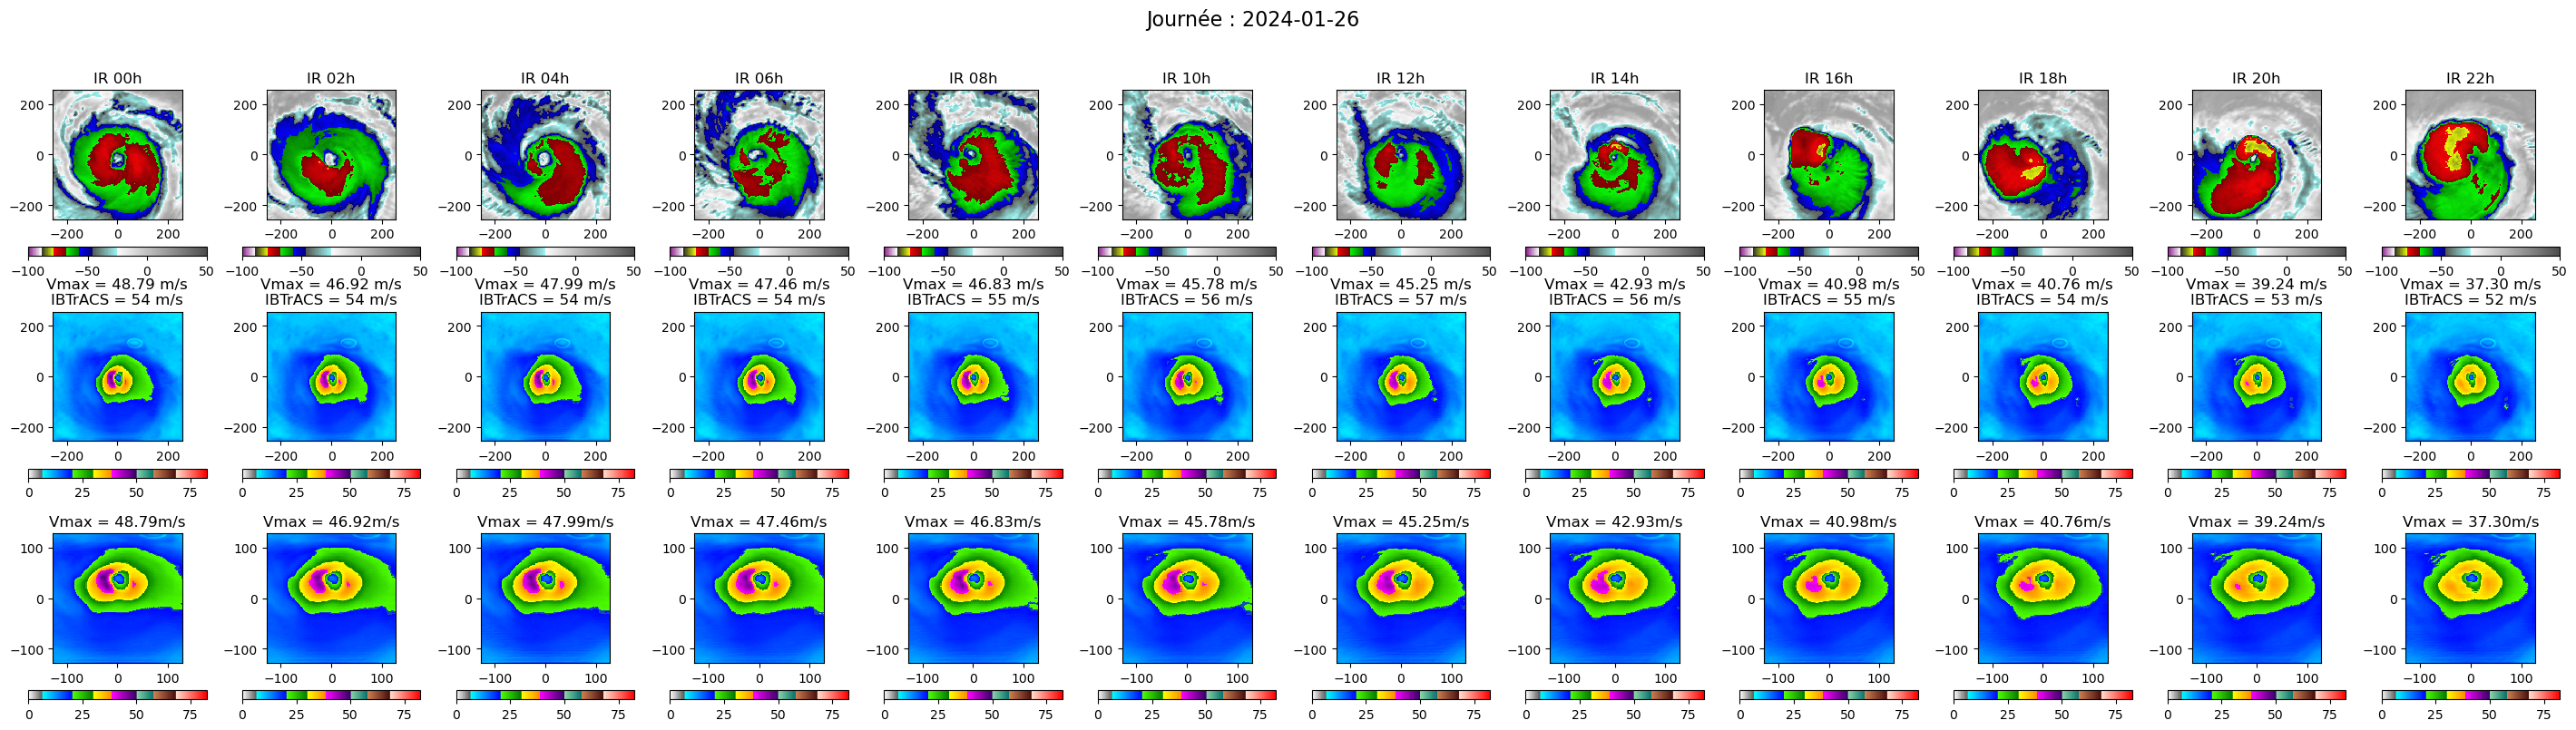

In [21]:
import pandas as pd
anggrek = pd.read_csv("https://cyclobs.ifremer.fr/app/api/track?sid=sh062024&freq=120&source=atcf&min_date=2024-01-13&max_date=2024-01-31")
index = 13 # 13 janvier
pred = preds[index]
ir = tensor[index] - 273.15  # Convertir en °C*
fig, axes = plt.subplots(3, 12, figsize=(36, 9))
for c in range(ir.shape[0]):
    plot_ir(ir[c], fig=fig, ax=axes[0,c], x_lim=256);axes[0,c].set_title(f"IR {c*2:02d}h")
    plot_sar(pred[c], fig=fig, ax=axes[1,c], x_lim=256);axes[1,c].set_title(f"Vmax = {np.nanmax(pred[c]):.2f} m/s\nIBTrACS = {anggrek.iloc[index*12+c]['wind_speed (m/s)']} m/s")
    pred_128 = pred[c][256//2-128--2:256//2+128//2,256//2-128//2:256//2+128//2]
    plot_sar(pred_128, fig=fig, x_lim=128, ax=axes[2,c]);axes[2,c].set_title(f"Vmax = {np.nanmax(pred_128):.2f}m/s")
plt.suptitle(f"Journée : {dates[index]}", fontsize=16)

Nombre d'observations Anggrek sur la période : 216
                 date  wind_speed (m/s) source
0 2024-01-13 00:00:00                10   atcf
1 2024-01-13 02:00:00                10   atcf
2 2024-01-13 04:00:00                10   atcf
3 2024-01-13 06:00:00                10   atcf
4 2024-01-13 08:00:00                11   atcf


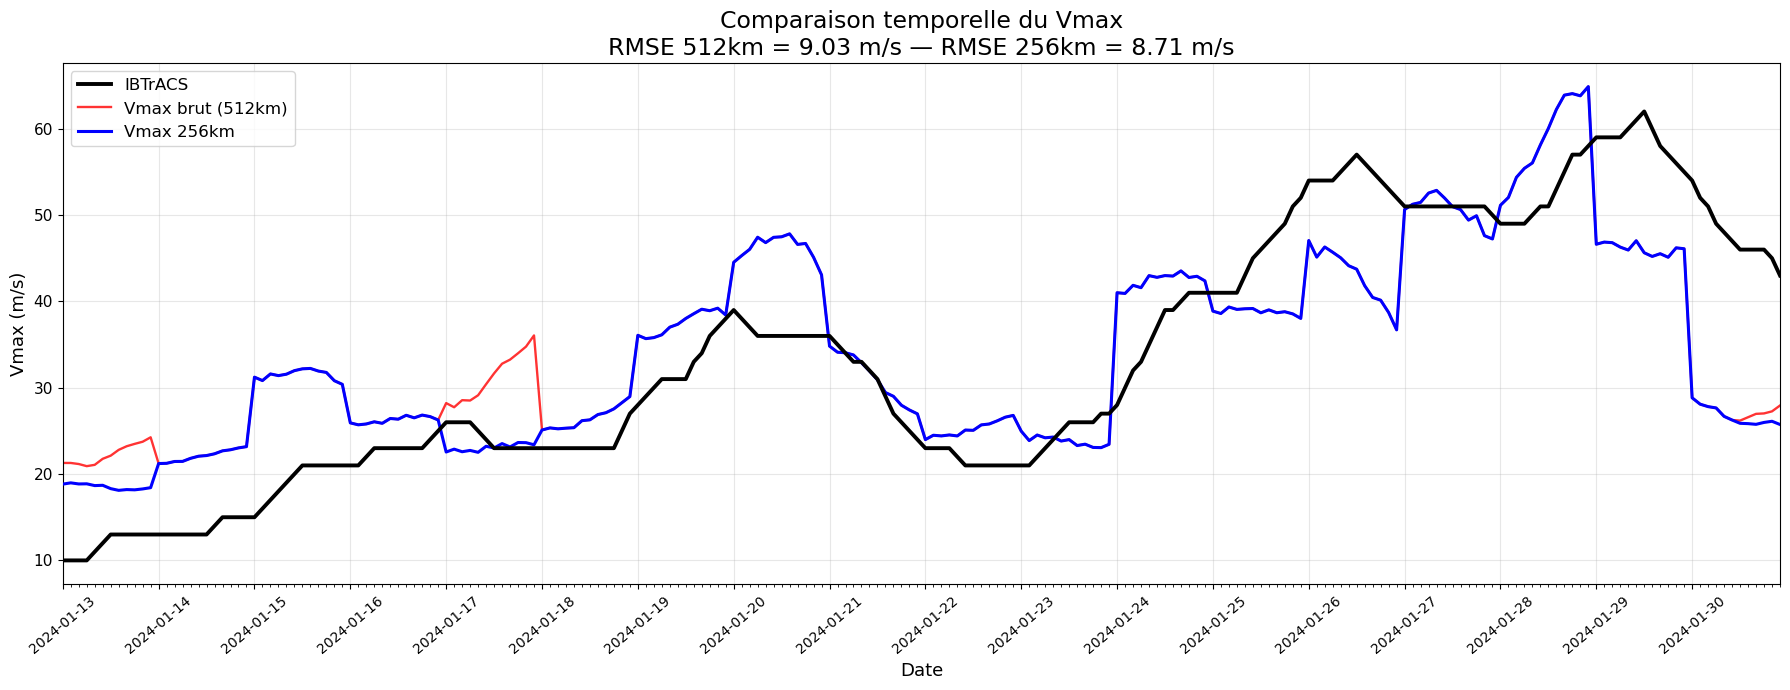

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

preds = np.asarray(
    preds,
    dtype=np.float32,
)

if preds.ndim != 4:
    raise ValueError(
        "preds doit avoir la forme (N_jours, 12, H, W), "
        f"mais la forme reçue est {preds.shape}"
    )

for n in range(preds.shape[0]):
    for c in range(preds.shape[1]):
        preds[n,c] = robust_vmax(preds[n,c], median_size=7,percentile=1)[1]

number_of_days = preds.shape[0]
number_of_hours = preds.shape[1]

if number_of_hours != 12:
    raise ValueError(
        f"12 prédictions sont attendues par jour, reçu : {number_of_hours}"
    )

start_date = pd.Timestamp("2024-01-13 00:00:00")
end_date = pd.Timestamp("2024-01-30 22:00:00")

model_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="2h",
)

expected_number = (
    number_of_days
    * number_of_hours
)

if len(model_dates) != expected_number:
    raise ValueError(
        f"Nombre de dates générées : {len(model_dates)}, "
        f"nombre de prédictions : {expected_number}"
    )

vmax_raw_series = []
vmax_robust_series = []

for day_index in range(number_of_days):

    for channel_index in range(number_of_hours):

        wind_field = preds[
            day_index,
            channel_index,
        ]

        finite_values = wind_field[
            np.isfinite(wind_field)
        ]

        if finite_values.size == 0:
            vmax_raw = np.nan
            vmax_robust = np.nan

        else:
            vmax_raw = float(
                np.nanmax(wind_field)
            )

            vmax_robust = np.nanmax(wind_field[256//2-128//2:256//2+128//2,256//2-128//2:256//2+128//2])

        vmax_raw_series.append(vmax_raw)
        vmax_robust_series.append(vmax_robust)

vmax_raw_series = np.asarray(
    vmax_raw_series,
    dtype=np.float32,
)

vmax_robust_series = np.asarray(
    vmax_robust_series,
    dtype=np.float32,
)

anggrek_plot = anggrek.copy()

anggrek_plot["date"] = pd.to_datetime(
    anggrek_plot["date"],
    errors="coerce",
    utc=True,
)

# Retirer le fuseau horaire pour comparer avec model_dates
anggrek_plot["date"] = (
    anggrek_plot["date"]
    .dt.tz_convert(None)
)

anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
    anggrek_plot["wind_speed (m/s)"],
    errors="coerce",
)

anggrek_plot = anggrek_plot.dropna(
    subset=[
        "date",
        "wind_speed (m/s)",
    ]
)

anggrek_plot = anggrek_plot[
    (
        anggrek_plot["date"]
        >= start_date
    )
    &
    (
        anggrek_plot["date"]
        <= end_date
    )
].copy()

anggrek_plot = anggrek_plot.sort_values(
    "date"
)

print(
    "Nombre d'observations Anggrek sur la période :",
    len(anggrek_plot),
)

print(
    anggrek_plot[
        [
            "date",
            "wind_speed (m/s)",
            "source",
        ]
    ].head()
)
anggrek_by_date = (
    anggrek_plot
    .groupby(
        "date",
        as_index=False,
    )
    .agg(
        {
            "wind_speed (m/s)": "mean",
        }
    )
    .sort_values("date")
)

comparison_df = pd.DataFrame(
    {
        "date": model_dates,
        "vmax_raw": vmax_raw_series,
        "vmax_robust": vmax_robust_series,
    }
)
comparison_df = comparison_df.merge(
    anggrek_by_date.rename(
        columns={
            "wind_speed (m/s)": "ibtracs_vmax"
        }
    ),
    on="date",
    how="left",
)
def compute_metrics(
    observations,
    predictions,
):
    observations = np.asarray(
        observations,
        dtype=np.float64,
    )

    predictions = np.asarray(
        predictions,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(observations)
        &
        np.isfinite(predictions)
    )

    if valid.sum() == 0:
        return {
            "n": 0,
            "rmse": np.nan,
            "mae": np.nan,
            "bias": np.nan,
            "correlation": np.nan,
        }

    obs = observations[valid]
    pred = predictions[valid]

    rmse = np.sqrt(
        np.mean(
            (pred - obs) ** 2
        )
    )

    mae = np.mean(
        np.abs(pred - obs)
    )

    bias = np.mean(
        pred - obs
    )

    if len(obs) >= 2:
        correlation = np.corrcoef(
            obs,
            pred,
        )[0, 1]
    else:
        correlation = np.nan

    return {
        "n": int(valid.sum()),
        "rmse": float(rmse),
        "mae": float(mae),
        "bias": float(bias),
        "correlation": float(correlation),
    }
    
metrics_raw = compute_metrics(
    comparison_df["ibtracs_vmax"],
    comparison_df["vmax_raw"],
)

metrics_robust = compute_metrics(
    comparison_df["ibtracs_vmax"],
    comparison_df["vmax_robust"],
)

fig, ax = plt.subplots(
    figsize=(18, 7),
)

ax.plot(
    comparison_df["date"],
    comparison_df["ibtracs_vmax"],
    color="black",
    linewidth=2.8,
    label="IBTrACS",
    zorder=4,
)

ax.plot(
    comparison_df["date"],
    comparison_df["vmax_raw"],
    color="red",
    linewidth=1.7,
    alpha=0.8,
    label="Vmax brut (512km)",
    zorder=2,
)

ax.plot(
    comparison_df["date"],
    comparison_df["vmax_robust"],
    color="blue",
    linewidth=2.2,
    label="Vmax 256km",
    zorder=3,
)

ax.set_title(
    "Comparaison temporelle du Vmax\n"
    f"RMSE 512km = {metrics_raw['rmse']:.2f} m/s — "
    f"RMSE 256km = {metrics_robust['rmse']:.2f} m/s",
    fontsize=17,
)

ax.set_xlabel(
    "Date",
    fontsize=13,
)

ax.set_ylabel(
    "Vmax (m/s)",
    fontsize=13,
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    fontsize=12,
    loc="best",
)

# Une seule date affichée par journée
ax.xaxis.set_major_locator(
    mdates.DayLocator(
        interval=1
    )
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%Y-%m-%d"
    )
)

# Petits repères toutes les 2 heures,
# sans réécrire le texte des heures
ax.xaxis.set_minor_locator(
    mdates.HourLocator(
        byhour=list(
            range(0, 24, 2)
        )
    )
)

ax.tick_params(
    axis="x",
    which="major",
    rotation=40,
    labelsize=10,
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.set_xlim(
    comparison_df["date"].min(),
    comparison_df["date"].max(),
)

plt.tight_layout()
plt.show()

In [23]:
#prediction de la journée 26 anvier avec overlap chaque 2heures 
from datetime import datetime, timedelta
import numpy as np


def build_overlapping_sequences(tensor, dates, seq_len=12):
    N, C, H, W = tensor.shape
    assert C == 12

    all_images = []
    all_times = []

    for i, day_str in enumerate(dates):

        day = datetime.strptime(str(day_str), "%Y-%m-%d")

        for c, hour in enumerate(range(0, 24, 2)):

            all_images.append(tensor[i, c])

            all_times.append(
                day + timedelta(hours=hour)
            )

    all_images = np.stack(all_images, axis=0)
    all_times = np.array(all_times, dtype=object)

    sequences = []
    seq_times = []

    for start in range(len(all_images) - seq_len + 1):

        end = start + seq_len

        times = all_times[start:end]

        # vérifier continuité exacte de 2 h
        valid = all(
            times[k + 1] - times[k] == timedelta(hours=2)
            for k in range(seq_len - 1)
        )

        if not valid:
            continue

        sequences.append(
            all_images[start:end]
        )

        seq_times.append(times)

    sequences = np.stack(sequences, axis=0)
    seq_times = np.stack(seq_times, axis=0)

    return sequences, seq_times

In [24]:
tensor_overlap, times_overlap = build_overlapping_sequences(
    tensor,
    dates,
    seq_len=12
)

print("tensor original :", tensor.shape)
print("tensor overlap :", tensor_overlap.shape)
print("times overlap :", times_overlap.shape)

tensor_normalized_overlap = np.zeros_like(
    tensor_overlap,
    dtype=np.float32
)
for c in range(12):

    tensor_normalized_overlap[:, c] = (
        tensor_overlap[:, c]
        - 273.15
        - mean_x
    ) / std_x

tensor original : (18, 12, 256, 256)
tensor overlap : (205, 12, 256, 256)
times overlap : (205, 12)


In [25]:
preds_overlap = []
model.to(device)
from tqdm import tqdm
for day in tqdm(tensor_normalized_overlap, desc="Inférence", total=tensor_normalized_overlap.shape[0]):
    day_torch = torch.from_numpy(day).unsqueeze(0).to(device)  # (1, 12, H, W)
    day_pred = model(day_torch, timestep=0).sample.squeeze().unsqueeze(1).detach().cpu().numpy() # (1,12, H, W)
    reconst_model = []
    for c in range(day_pred.shape[0]):
        reconst_model.append(dataprep.annular_denormalization(day_pred[c], stats = {"mean": mean_y, "std": std_y})[0].astype(np.float32).squeeze())
    preds_overlap.append(np.stack(reconst_model, axis=0))  # (12, H, W)
preds_overlap = np.stack(preds_overlap, axis=0)  # (N, 12, H, W)
preds_overlap.shape, tensor.shape

Inférence: 100%|██████████| 205/205 [03:01<00:00,  1.13it/s]


((205, 12, 256, 256), (18, 12, 256, 256))

In [26]:
with open("predictions_00_22.pkl","wb") as f:
    pkl.dump({"irwin":tensor,"wind":preds_overlap,"time":times_overlap},f)

In [27]:
from collections import defaultdict

preds_by_time = defaultdict(list)

for i in range(preds_overlap.shape[0]):
    for c in range(12):
        preds_by_time[times_overlap[i, c]].append(
            preds_overlap[i, c]
        )

Text(0.5, 0.98, '2024-01-25 12:00:00')

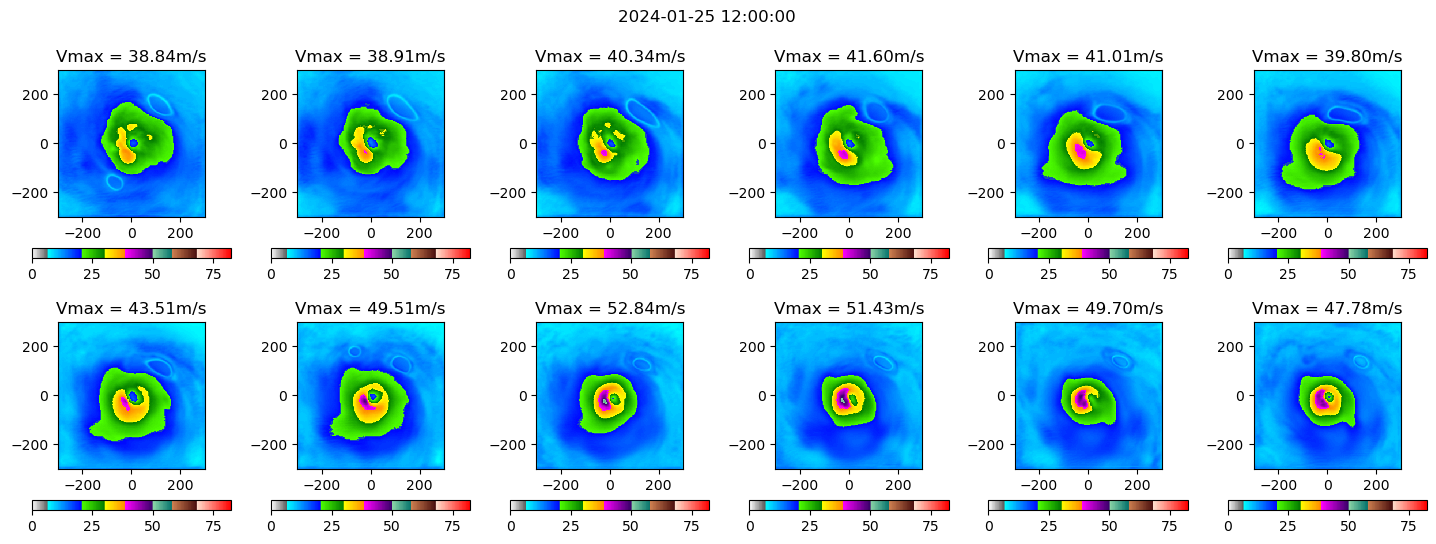

In [28]:
t = datetime(2024, 1, 25, 12)

fig, axes = plt.subplots(2,6,figsize=(18,6))

for i in range(2):
    for j in range(6):
        plot_sar(preds_by_time[t][i*6+j], fig=fig, ax=axes[i,j]);axes[i,j].set_title(f"Vmax = {np.nanmax(preds_by_time[t][i*6+j]):.2f}m/s")
plt.suptitle(f"{str(t)}")

In [29]:
from collections import defaultdict

preds_by_time_info = defaultdict(list)

for i in range(preds_overlap.shape[0]):

    window_start = times_overlap[i, 0]
    window_end   = times_overlap[i, -1]

    for c in range(12):

        t = times_overlap[i, c]

        preds_by_time_info[t].append({
            "prediction": preds_overlap[i, c],
            "channel": c,
            "sequence": i,
            "window_start": window_start,
            "window_end": window_end,
        })

In [30]:
START_HOUR = 00

In [31]:
start_date = pd.Timestamp("2024-01-14 00:00:00")
end_date   = pd.Timestamp("2024-01-29 22:00:00")


selected_predictions = []

for t in sorted(preds_by_time_info):

    t_pd = pd.Timestamp(t)

    if not (start_date <= t_pd <= end_date):
        continue

    candidates = [
        item
        for item in preds_by_time_info[t]
        if item["window_start"].hour == START_HOUR
    ]

    if len(candidates) == 0:
        continue

    if len(candidates) > 1:
        print(
            "Attention:",
            t,
            "possède",
            len(candidates),
            "candidats"
        )

    item = candidates[0]

    selected_predictions.append({
        "date": t_pd,
        "prediction": item["prediction"],
        "channel": item["channel"],
        "window_start": item["window_start"],
    })

rows = []

for item in selected_predictions:

    wind_field = item["prediction"].copy()

    finite_values = wind_field[np.isfinite(wind_field)]

    if finite_values.size == 0:

        vmax_raw = np.nan
        vmax_robust = np.nan

    else:

        vmax_raw = float(
            np.nanmax(wind_field)
        )

        vmax_robust, _ = robust_vmax(
            wind=wind_field,
            percentile=99.5,
            median_size=3,
        )

    rows.append({
        "date": item["date"],
        "vmax_raw": vmax_raw,
        "vmax_robust": vmax_robust,
        "channel": item["channel"],
        "window_start": item["window_start"],
    })

anggrek_plot = anggrek.copy()

anggrek_plot["date"] = pd.to_datetime(
    anggrek_plot["date"],
    errors="coerce",
    utc=True,
)

anggrek_plot["date"] = (
    anggrek_plot["date"]
    .dt.tz_convert(None)
)

anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
    anggrek_plot["wind_speed (m/s)"],
    errors="coerce",
)

anggrek_plot = anggrek_plot.dropna(
    subset=[
        "date",
        "wind_speed (m/s)",
    ]
)

anggrek_plot = anggrek_plot[
    (anggrek_plot["date"] >= start_date)
    &
    (anggrek_plot["date"] <= end_date)
].copy()


anggrek_by_date = (
    anggrek_plot
    .groupby("date", as_index=False)
    .agg({
        "wind_speed (m/s)": "mean"
    })
    .sort_values("date")
)



comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.merge(
    anggrek_by_date.rename(
        columns={
            "wind_speed (m/s)": "ibtracs_vmax"
        }
    ),
    on="date",
    how="left",
)
metrics_raw = compute_metrics(
    comparison_df["ibtracs_vmax"],
    comparison_df["vmax_raw"],
)

metrics_robust = compute_metrics(
    comparison_df["ibtracs_vmax"],
    comparison_df["vmax_robust"],
)

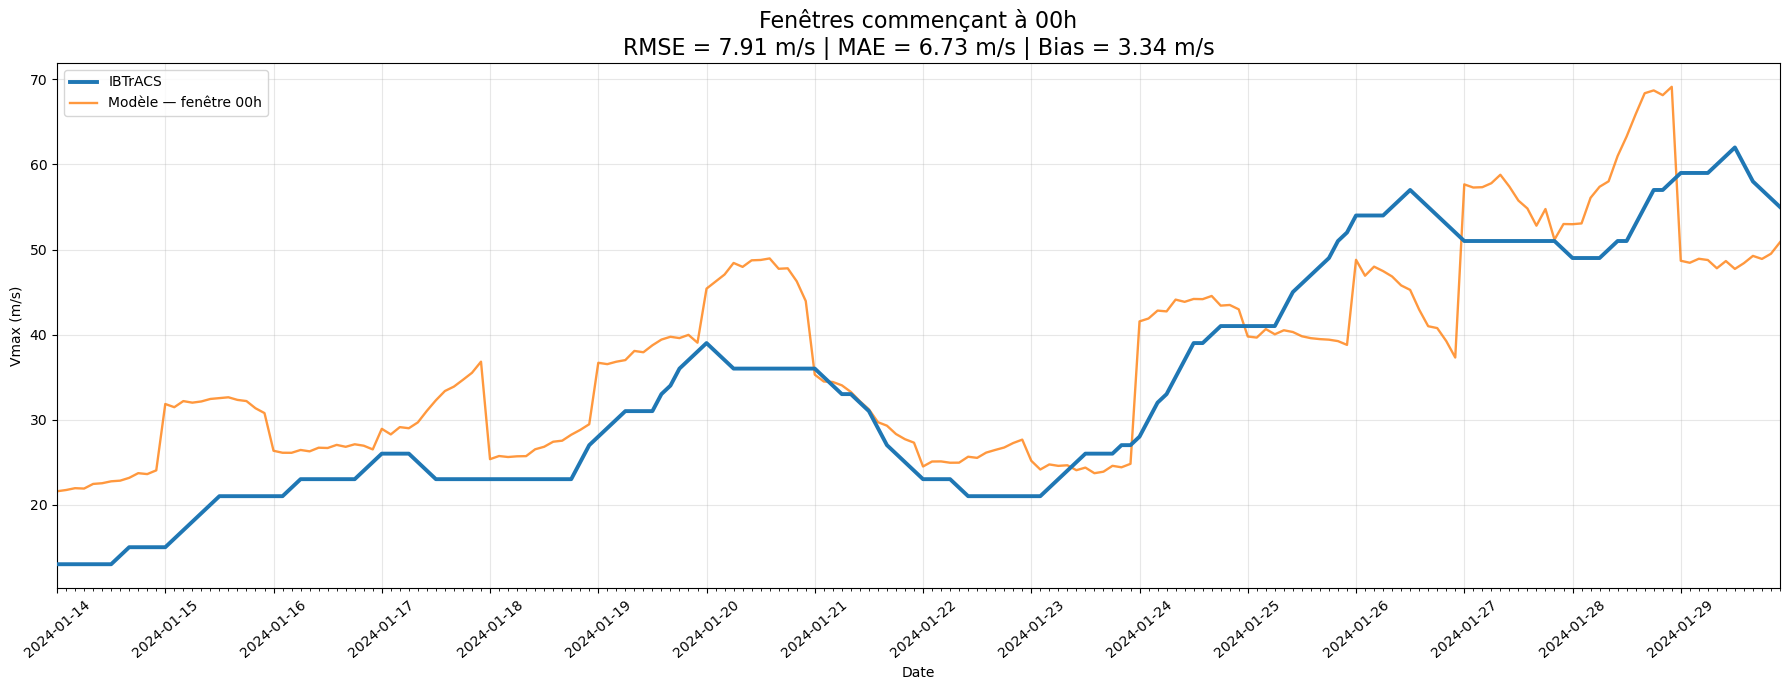

In [32]:
fig, ax = plt.subplots(
    figsize=(18, 7)
)

ax.plot(
    comparison_df["date"],
    comparison_df["ibtracs_vmax"],
    linewidth=2.8,
    label="IBTrACS",
    zorder=4,
)

ax.plot(
    comparison_df["date"],
    comparison_df["vmax_raw"],
    linewidth=1.7,
    alpha=0.8,
    label=f"Modèle — fenêtre {START_HOUR:02d}h",
    zorder=2,
)

ax.set_title(
    f"Fenêtres commençant à {START_HOUR:02d}h\n"
    f"RMSE = {metrics_raw['rmse']:.2f} m/s | "
    f"MAE = {metrics_raw['mae']:.2f} m/s | "
    f"Bias = {metrics_raw['bias']:.2f} m/s",
    fontsize=16,
)

ax.set_xlabel("Date")
ax.set_ylabel("Vmax (m/s)")

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m-%d")
)

ax.xaxis.set_minor_locator(
    mdates.HourLocator(
        byhour=list(range(0, 24, 2))
    )
)

ax.tick_params(
    axis="x",
    rotation=40
)

ax.set_xlim(
    start_date,
    end_date
)

plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------------
# 1. Période
# ---------------------------------------------------------
start_date = pd.Timestamp("2024-01-14 00:00:00")
end_date   = pd.Timestamp("2024-01-29 22:00:00")


# ---------------------------------------------------------
# 2. Moyenne des prédictions pour chaque timestamp
# ---------------------------------------------------------
rows = []
mean_predictions_by_time = {}

for t in sorted(preds_by_time):

    t_pd = pd.Timestamp(t)

    if not (start_date <= t_pd <= end_date):
        continue

    # Toutes les prédictions disponibles pour cette heure
    # shape : (N_predictions, 256, 256)
    predictions_t = np.stack(
        preds_by_time[t],
        axis=0
    )

    # Moyenne pixel par pixel
    mean_prediction = np.nanmean(
        predictions_t,
        axis=0
    )

    mean_predictions_by_time[t] = mean_prediction

    # Vmax brut de la carte moyenne
    vmax_raw = float(
        np.nanmax(mean_prediction)
    )

    # Vmax robuste de la carte moyenne
    vmax_robust, _ = robust_vmax(
        wind=mean_prediction,
        percentile=99.5,
        median_size=3,
    )

    rows.append({
        "date": t_pd,
        "vmax_mean": vmax_raw,
        "vmax_mean_robust": vmax_robust,
        "n_predictions": len(preds_by_time[t]),
    })


comparison_mean_df = pd.DataFrame(rows)

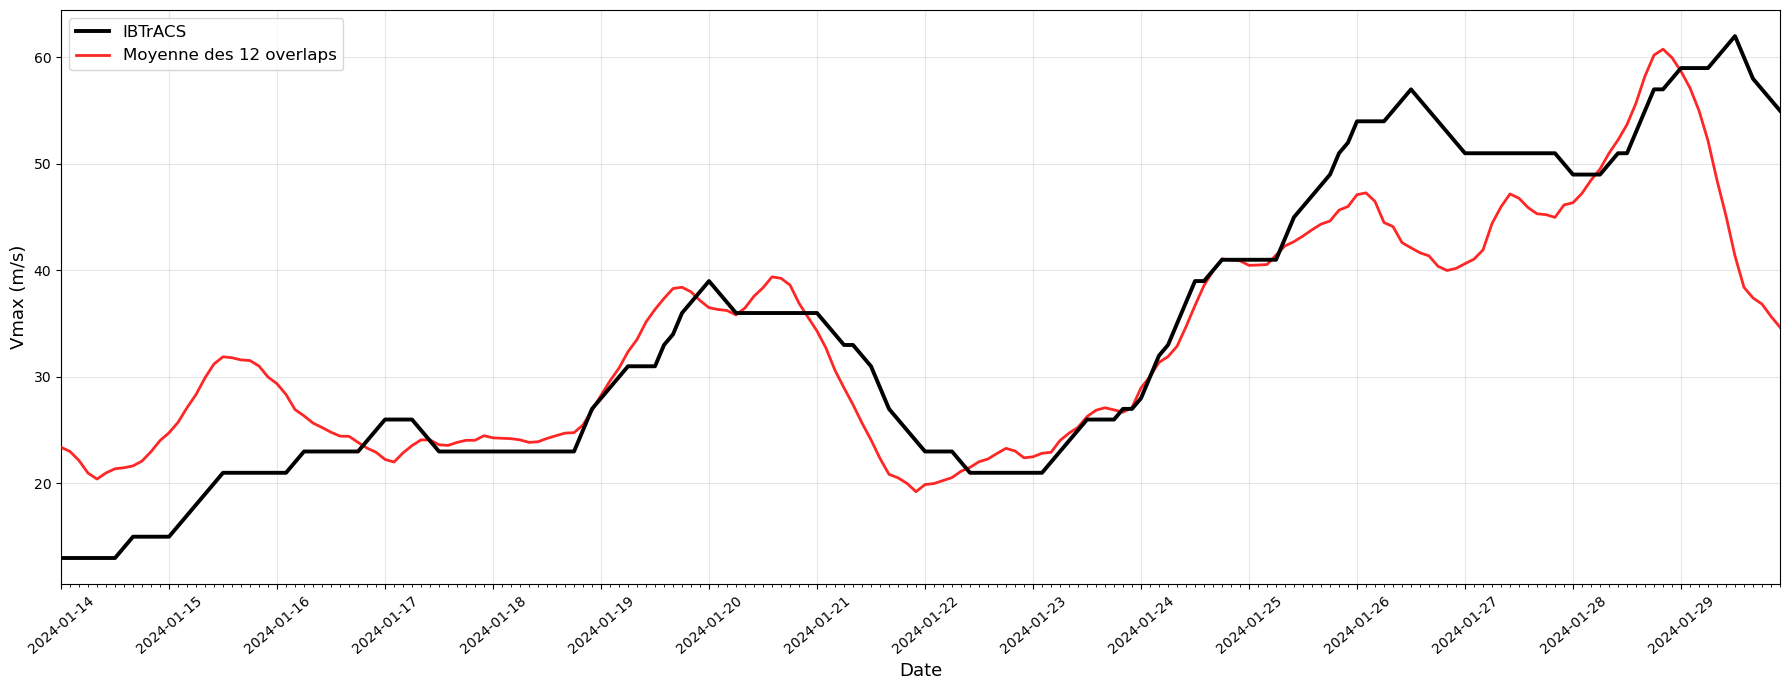

In [34]:
# ---------------------------------------------------------
# 3. IBTrACS
# ---------------------------------------------------------
anggrek_plot = anggrek.copy()

anggrek_plot["date"] = pd.to_datetime(
    anggrek_plot["date"],
    errors="coerce",
    utc=True,
)

anggrek_plot["date"] = (
    anggrek_plot["date"]
    .dt.tz_convert(None)
)

anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
    anggrek_plot["wind_speed (m/s)"],
    errors="coerce",
)

anggrek_plot = anggrek_plot.dropna(
    subset=[
        "date",
        "wind_speed (m/s)"
    ]
)

anggrek_plot = anggrek_plot[
    (anggrek_plot["date"] >= start_date)
    &
    (anggrek_plot["date"] <= end_date)
].copy()

anggrek_by_date = (
    anggrek_plot
    .groupby("date", as_index=False)
    .agg({
        "wind_speed (m/s)": "mean"
    })
    .sort_values("date")
)

comparison_mean_df = comparison_mean_df.merge(
    anggrek_by_date.rename(
        columns={
            "wind_speed (m/s)": "ibtracs_vmax"
        }
    ),
    on="date",
    how="left"
)

fig, ax = plt.subplots(
    figsize=(18, 7)
)

ax.plot(
    comparison_mean_df["date"],
    comparison_mean_df["ibtracs_vmax"],
    color="black",
    linewidth=2.8,
    label="IBTrACS",
    zorder=4,
)

ax.plot(
    comparison_mean_df["date"],
    comparison_mean_df["vmax_mean"],
    color="red",
    linewidth=2.0,
    alpha=0.85,
    label="Moyenne des 12 overlaps",
    zorder=3,
)


ax.set_xlabel(
    "Date",
    fontsize=13
)

ax.set_ylabel(
    "Vmax (m/s)",
    fontsize=13
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend(
    fontsize=12,
    loc="best"
)

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m-%d")
)

ax.xaxis.set_minor_locator(
    mdates.HourLocator(
        byhour=range(0, 24, 2)
    )
)

ax.tick_params(
    axis="x",
    which="major",
    rotation=40,
    labelsize=10
)

ax.set_xlim(
    start_date,
    end_date
)

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Journée : 2024-01-28')

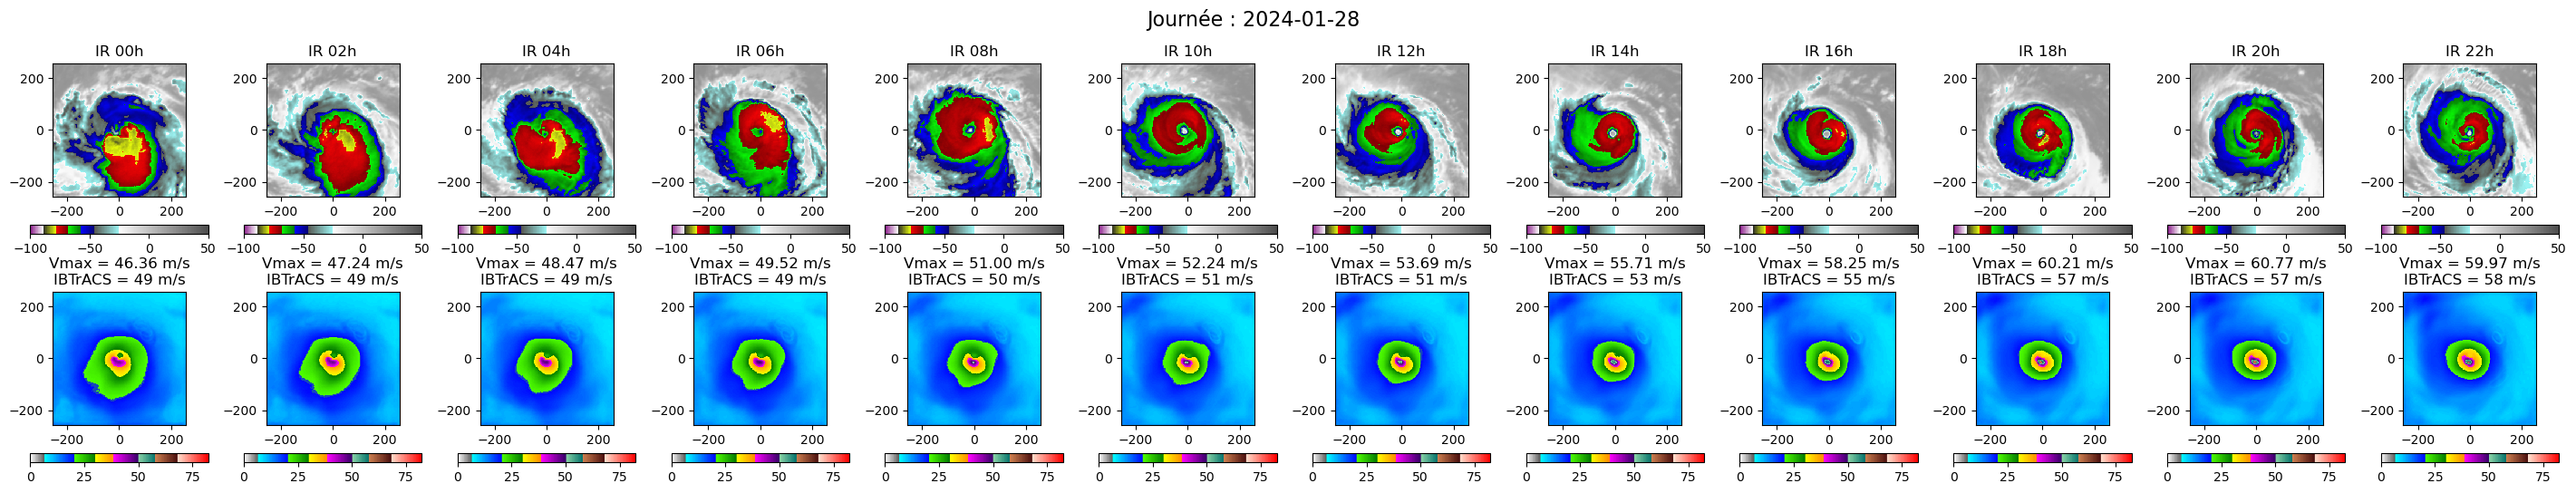

In [35]:
import pandas as pd
anggrek = pd.read_csv("https://cyclobs.ifremer.fr/app/api/track?sid=sh062024&freq=120&source=atcf&min_date=2024-01-13&max_date=2024-01-31")
index = 15 # 13 janvier
ir = tensor[index] - 273.15  # Convertir en °C*
fig, axes = plt.subplots(2, 12, figsize=(36, 6))
for c in range(ir.shape[0]):
    t = datetime(2024, 1, 13 + index, c*2)
    plot_ir(ir[c], fig=fig, ax=axes[0,c], x_lim=256);axes[0,c].set_title(f"IR {c*2:02d}h")
    plot_sar(mean_predictions_by_time[t], fig=fig, ax=axes[1,c], x_lim=256);axes[1,c].set_title(f"Vmax = {np.nanmax(mean_predictions_by_time[t]):.2f} m/s\nIBTrACS = {anggrek.iloc[index*12+c]['wind_speed (m/s)']} m/s")
plt.suptitle(f"Journée : {dates[index]}", fontsize=16)

Text(0.5, 0.98, 'Journée : 2024-01-26')

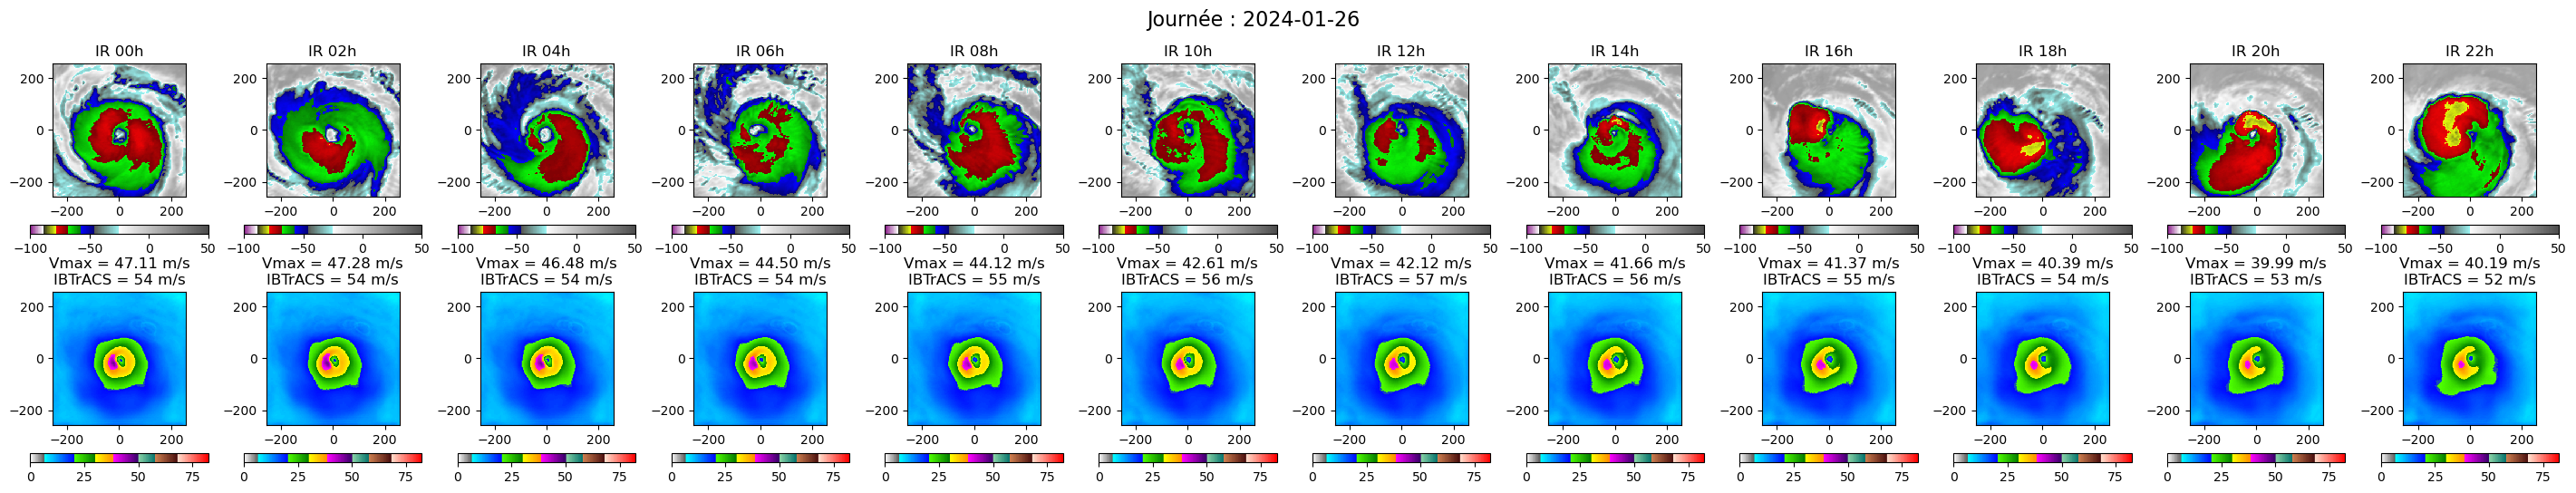

In [36]:
import pandas as pd
anggrek = pd.read_csv("https://cyclobs.ifremer.fr/app/api/track?sid=sh062024&freq=120&source=atcf&min_date=2024-01-13&max_date=2024-01-31")
index = 13 # 13 janvier
ir = tensor[index] - 273.15  # Convertir en °C*
fig, axes = plt.subplots(2, 12, figsize=(36, 6))
for c in range(ir.shape[0]):
    t = datetime(2024, 1, 13 + index, c*2)
    plot_ir(ir[c], fig=fig, ax=axes[0,c], x_lim=256);axes[0,c].set_title(f"IR {c*2:02d}h")
    plot_sar(mean_predictions_by_time[t], fig=fig, ax=axes[1,c], x_lim=256);axes[1,c].set_title(f"Vmax = {np.nanmax(mean_predictions_by_time[t]):.2f} m/s\nIBTrACS = {anggrek.iloc[index*12+c]['wind_speed (m/s)']} m/s")
plt.suptitle(f"Journée : {dates[index]}", fontsize=16)

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def build_comparison_df_for_delta(
    delta_t,
    preds_by_time_info,
    anggrek,
    start_date,
    end_date,
):
    if delta_t % 2 != 0:
        raise ValueError(
            "delta_t doit être un multiple de 2 heures."
        )

    CENTER_CHANNEL = 6

    target_channel = CENTER_CHANNEL - delta_t // 2

    if not (0 <= target_channel < 12):
        raise ValueError(
            f"delta_t={delta_t} h donne le channel "
            f"{target_channel}, hors de [0, 11]."
        )

    selected_predictions = []

    for t in sorted(preds_by_time_info):

        t_pd = pd.Timestamp(t)

        if not (start_date <= t_pd <= end_date):
            continue

        candidates = [
            item
            for item in preds_by_time_info[t]
            if item["channel"] == target_channel
        ]

        if len(candidates) == 0:
            continue

        item = candidates[0]

        selected_predictions.append({
            "date": t_pd,
            "prediction": item["prediction"],
            "channel": item["channel"],
            "sequence": item["sequence"],
            "window_start": item["window_start"],
            "window_end": item["window_end"],
        })

    rows = []

    for item in selected_predictions:

        wind_field = item["prediction"]

        finite_values = wind_field[
            np.isfinite(wind_field)
        ]

        if finite_values.size == 0:
            vmax_raw = np.nan
            vmax_robust = np.nan

        else:
            vmax_raw = float(
                np.nanmax(wind_field)
            )

            vmax_robust, _ = robust_vmax(
                wind=wind_field,
                percentile=99.5,
                median_size=3,
            )

        rows.append({
            "date": item["date"],
            "vmax_raw": vmax_raw,
            "vmax_robust": vmax_robust,
            "channel": item["channel"],
            "window_start": item["window_start"],
            "window_end": item["window_end"],
        })

    comparison_df = pd.DataFrame(rows)

    anggrek_plot = anggrek.copy()

    anggrek_plot["date"] = pd.to_datetime(
        anggrek_plot["date"],
        errors="coerce",
        utc=True,
    )

    anggrek_plot["date"] = (
        anggrek_plot["date"]
        .dt.tz_convert(None)
    )

    anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
        anggrek_plot["wind_speed (m/s)"],
        errors="coerce",
    )

    anggrek_plot = anggrek_plot.dropna(
        subset=[
            "date",
            "wind_speed (m/s)",
        ]
    )

    anggrek_plot = anggrek_plot[
        (anggrek_plot["date"] >= start_date)
        &
        (anggrek_plot["date"] <= end_date)
    ].copy()

    anggrek_by_date = (
        anggrek_plot
        .groupby("date", as_index=False)
        .agg({
            "wind_speed (m/s)": "mean"
        })
        .sort_values("date")
    )

    comparison_df = comparison_df.merge(
        anggrek_by_date.rename(
            columns={
                "wind_speed (m/s)": "ibtracs_vmax"
            }
        ),
        on="date",
        how="left",
    )

    metrics_raw = compute_metrics(
        comparison_df["ibtracs_vmax"],
        comparison_df["vmax_raw"],
    )

    return comparison_df, metrics_raw

def plot_delta(delta_t):
    
    start_date = pd.Timestamp("2024-01-14 00:00:00")
    end_date   = pd.Timestamp("2024-01-29 22:00:00")

    fig, ax = plt.subplots(figsize=(18, 7))

    # ========================================================
    # CASE 1 : moyenne de tous les delta
    # ========================================================
    if delta_t == "mean":

        rows = []

        for t in sorted(preds_by_time_info):

            t_pd = pd.Timestamp(t)

            if not (start_date <= t_pd <= end_date):
                continue

            candidates = preds_by_time_info[t]

            if len(candidates) == 0:
                continue

            predictions = np.stack(
                [
                    item["prediction"]
                    for item in candidates
                ],
                axis=0,
            )

            # Moyenne pixel par pixel
            mean_prediction = np.nanmean(
                predictions,
                axis=0,
            )

            finite_values = mean_prediction[
                np.isfinite(mean_prediction)
            ]

            if finite_values.size == 0:
                vmax_raw = np.nan
                vmax_robust = np.nan

            else:
                vmax_raw = float(
                    np.nanmax(mean_prediction)
                )

                vmax_robust, _ = robust_vmax(
                    wind=mean_prediction,
                    percentile=99.5,
                    median_size=3,
                )

            rows.append({
                "date": t_pd,
                "vmax_raw": vmax_raw,
                "vmax_robust": vmax_robust,
                "n_predictions": len(candidates),
            })

        comparison_df = pd.DataFrame(rows)

        # IBTrACS
        anggrek_plot = anggrek.copy()

        anggrek_plot["date"] = pd.to_datetime(
            anggrek_plot["date"],
            errors="coerce",
            utc=True,
        )

        anggrek_plot["date"] = (
            anggrek_plot["date"]
            .dt.tz_convert(None)
        )

        anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
            anggrek_plot["wind_speed (m/s)"],
            errors="coerce",
        )

        anggrek_plot = anggrek_plot.dropna(
            subset=[
                "date",
                "wind_speed (m/s)",
            ]
        )

        anggrek_plot = anggrek_plot[
            (anggrek_plot["date"] >= start_date)
            &
            (anggrek_plot["date"] <= end_date)
        ]

        anggrek_by_date = (
            anggrek_plot
            .groupby("date", as_index=False)
            .agg({
                "wind_speed (m/s)": "mean"
            })
            .sort_values("date")
        )

        comparison_df = comparison_df.merge(
            anggrek_by_date.rename(
                columns={
                    "wind_speed (m/s)": "ibtracs_vmax"
                }
            ),
            on="date",
            how="left",
        )

        metrics = compute_metrics(
            comparison_df["ibtracs_vmax"],
            comparison_df["vmax_raw"],
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["ibtracs_vmax"],
            linewidth=2.8,
            label="IBTrACS",
            zorder=4,
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["vmax_raw"],
            linewidth=1.8,
            alpha=0.85,
            label="Mean reconstruction over all Δt",
            zorder=3,
        )

        ax.set_title(
            "Multi-temporal aggregation of wind field predictions\n"
            f"RMSE = {metrics['rmse']:.2f} m/s | "
            f"MAE = {metrics['mae']:.2f} m/s | "
            f"Bias = {metrics['bias']:.2f} m/s",
            fontsize=16,
        )

    # ========================================================
    # CASE 2 : delta = 0
    # ========================================================
    elif delta_t == 0:

        comparison_df, metrics = build_comparison_df_for_delta(
            delta_t=0,
            preds_by_time_info=preds_by_time_info,
            anggrek=anggrek,
            start_date=start_date,
            end_date=end_date,
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["ibtracs_vmax"],
            linewidth=2.8,
            label="IBTrACS",
            zorder=4,
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["vmax_raw"],
            linewidth=1.8,
            alpha=0.85,
            label="Model reconstruction — Δt = 0 h",
            zorder=3,
        )

        ax.set_title(
            f"Δt = 0 h | "
            f"RMSE = {metrics['rmse']:.2f} m/s | "
            f"MAE = {metrics['mae']:.2f} m/s | "
            f"Bias = {metrics['bias']:.2f} m/s",
            fontsize=16,
        )

    # ========================================================
    # CASE 3 : delta != 0
    # ========================================================
    else:

        delta_abs = abs(delta_t)

        comparison_plus, metrics_plus = (
            build_comparison_df_for_delta(
                delta_t=delta_abs,
                preds_by_time_info=preds_by_time_info,
                anggrek=anggrek,
                start_date=start_date,
                end_date=end_date,
            )
        )

        comparison_minus, metrics_minus = (
            build_comparison_df_for_delta(
                delta_t=-delta_abs,
                preds_by_time_info=preds_by_time_info,
                anggrek=anggrek,
                start_date=start_date,
                end_date=end_date,
            )
        )

        ax.plot(
            comparison_plus["date"],
            comparison_plus["ibtracs_vmax"],
            linewidth=2.8,
            label="IBTrACS",
            zorder=4,
        )

        ax.plot(
            comparison_plus["date"],
            comparison_plus["vmax_raw"],
            linewidth=1.8,
            alpha=0.85,
            label=f"Model reconstruction — Δt = +{delta_abs} h",
            zorder=3,
        )

        ax.plot(
            comparison_minus["date"],
            comparison_minus["vmax_raw"],
            linewidth=1.8,
            alpha=0.85,
            label=f"Model reconstruction — Δt = -{delta_abs} h",
            zorder=2,
        )

        ax.set_title(
            f"+{delta_abs} h: "
            f"RMSE={metrics_plus['rmse']:.2f}, "
            f"MAE={metrics_plus['mae']:.2f}, "
            f"Bias={metrics_plus['bias']:.2f} m/s | "
            f"-{delta_abs} h: "
            f"RMSE={metrics_minus['rmse']:.2f}, "
            f"MAE={metrics_minus['mae']:.2f}, "
            f"Bias={metrics_minus['bias']:.2f} m/s",
            fontsize=15,
        )

    # ========================================================
    # Mise en forme commune
    # ========================================================

    ax.set_xlabel("Date", fontsize=13)
    ax.set_ylabel("Vmax (m/s)", fontsize=13)

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=12)

    ax.xaxis.set_major_locator(
        mdates.DayLocator(interval=1)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m-%d")
    )

    ax.xaxis.set_minor_locator(
        mdates.HourLocator(
            byhour=list(range(0, 24, 2))
        )
    )

    ax.tick_params(
        axis="x",
        rotation=40,
    )

    ax.set_xlim(
        start_date,
        end_date,
    )

    plt.tight_layout()
    plt.show()

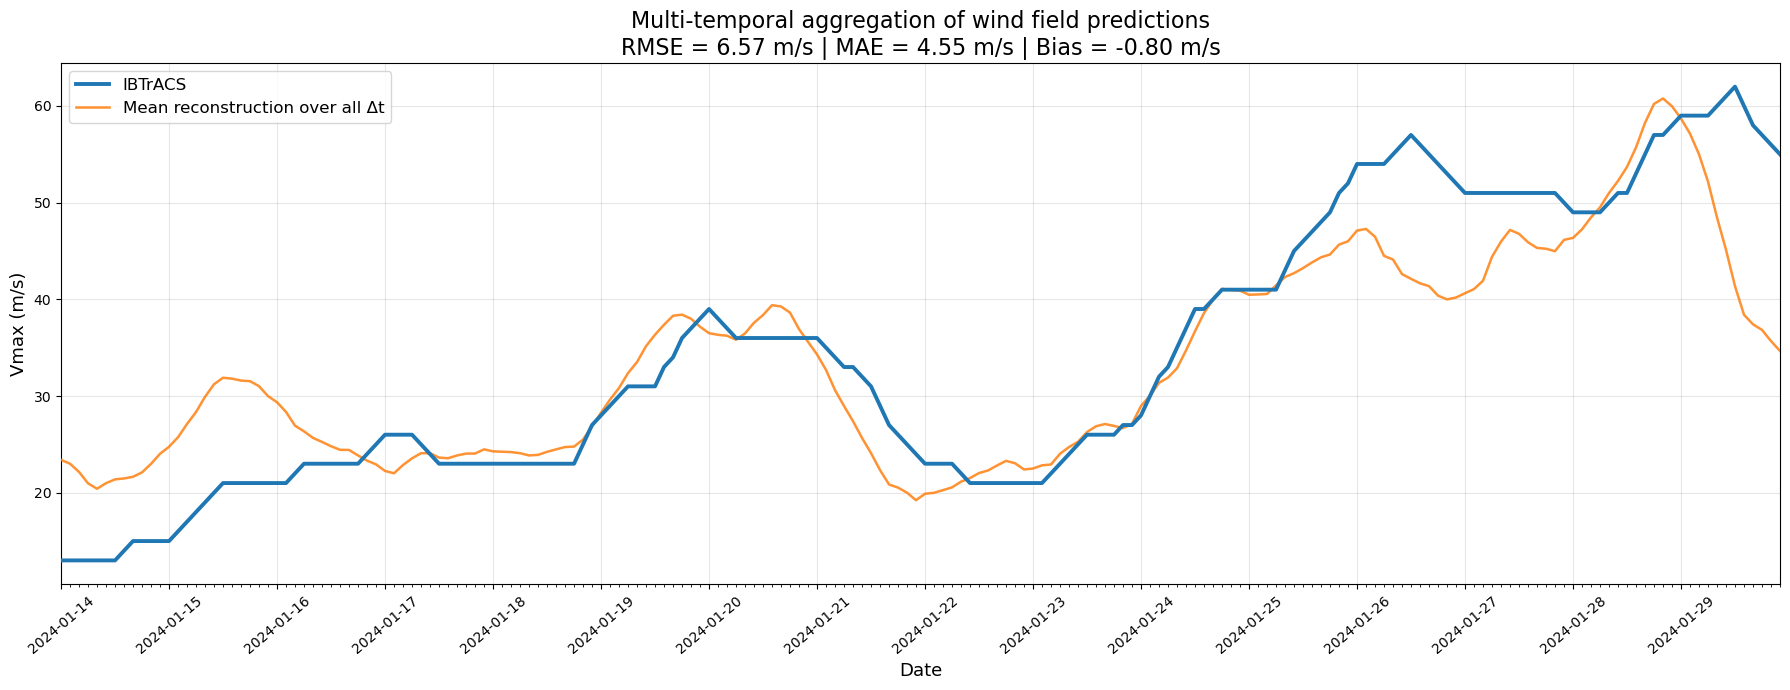

In [38]:
plot_delta("mean")